In [1]:
import pandas as pd
import numpy as np+

SyntaxError: cannot use name as import target (3274477486.py, line 2)

In [2]:
import pandas as pd
import numpy as np

In [7]:
nav = pd.read_csv("data/raw/02_nav_history.csv")
nav.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/02_nav_history.csv'

In [8]:
import os
os.getcwd()

'c:\\Users\\Shrutika\\Desktop\\MutualFundProject\\data\\raw'

In [9]:
nav = pd.read_csv("02_nav_history.csv")
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [11]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [12]:
var_report = nav.groupby("amfi_code")["daily_return"].apply(
    lambda x: np.percentile(x.dropna(), 5)
).reset_index()

var_report.columns = ["amfi_code", "VaR_95"]

var_report.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [13]:
def calculate_cvar(group):
    var = np.percentile(group.dropna(), 5)
    cvar = group[group <= var].mean()
    return cvar

cvar_report = nav.groupby("amfi_code")["daily_return"].apply(calculate_cvar).reset_index()

cvar_report.columns = ["amfi_code", "CVaR_95"]

cvar_report.head()

,amfi_code,CVaR_95
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [14]:
final_report = pd.merge(var_report, cvar_report, on="amfi_code")

final_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [15]:
final_report.to_csv("var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


In [16]:
import matplotlib.pyplot as plt

nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean() / x.rolling(90).std() * np.sqrt(252))
)

nav.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN


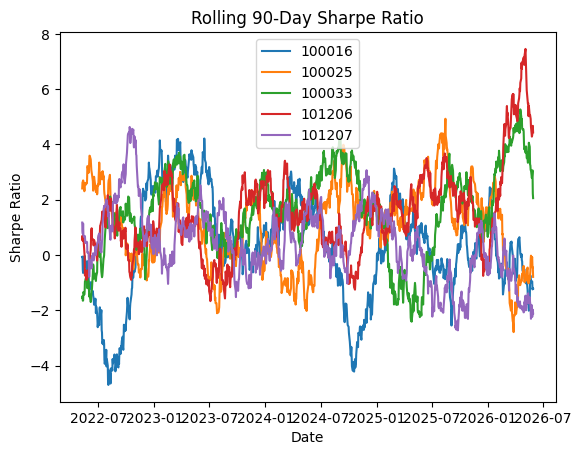

In [17]:
top5 = nav["amfi_code"].unique()[:5]

for fund in top5:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(fund))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.show()

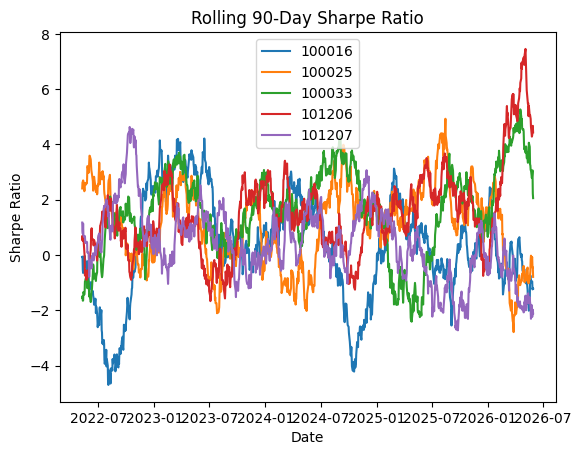

In [18]:
top5 = nav["amfi_code"].unique()[:5]

for fund in top5:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(fund))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.show()

In [19]:
transactions = pd.read_csv("08_investor_transactions.csv")
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [20]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

first_txn = transactions.groupby("investor_id")["transaction_date"].min().reset_index()

first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [21]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

first_txn = transactions.groupby("investor_id")["transaction_date"].min().reset_index()

first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [22]:
cohort_data = transactions.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

cohort_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [23]:
cohort_analysis = cohort_data.groupby("cohort_year").agg(
    avg_investment=("amount_inr", "mean"),
    total_investment=("amount_inr", "sum"),
    investors=("investor_id", "nunique")
).reset_index()

cohort_analysis

,cohort_year,avg_investment,total_investment,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [24]:
cohort_analysis.to_csv("cohort_analysis.csv", index=False)

print("cohort_analysis.csv saved successfully")

cohort_analysis.csv saved successfully


In [25]:
sip_data = transactions[transactions["transaction_type"] == "SIP"].copy()

sip_data = sip_data.sort_values(["investor_id", "transaction_date"])

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified


In [26]:
sip_data["gap_days"] = sip_data.groupby("investor_id")["transaction_date"].diff().dt.days

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,238.0


In [27]:
sip_continuity = sip_data.groupby("investor_id").agg(
    avg_gap_days=("gap_days", "mean")
).reset_index()

sip_continuity["risk_status"] = sip_continuity["avg_gap_days"].apply(
    lambda x: "At Risk" if x > 35 else "Safe"
)

sip_continuity.head()

,investor_id,avg_gap_days,risk_status
0,INV000001,76.0,At Risk
1,INV000002,207.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,85.4,At Risk
4,INV000005,14.0,Safe


In [28]:
sip_continuity.to_csv("sip_continuity.csv", index=False)

print("sip_continuity.csv saved successfully")

sip_continuity.csv saved successfully


In [29]:
performance = pd.read_csv("../processed/clean_performance.csv")

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [30]:
performance["risk_grade"] = performance["category"].apply(
    lambda x: "Low" if "Large Cap" in str(x)
    else ("Moderate" if "Mid Cap" in str(x)
    else "High")
)

performance["score"] = (
    performance["return_1yr_pct"] +
    performance["return_3yr_pct"] +
    performance["return_5yr_pct"]
) / 3

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Low,13.076667
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Low,13.593333
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,High,22.873333
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,High,21.850000
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,High,5.613333


In [31]:
risk_appetite = "Moderate"

recommended = performance[
    performance["risk_grade"] == risk_appetite
].sort_values(
    by="score",
    ascending=False
).head(3)

recommended[
    ["scheme_name", "category", "risk_grade", "score"]
]

,scheme_name,category,risk_grade,score
21,Kotak Emerging Equity Fund - Regular - Growth,Mid Cap,Moderate,17.70
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap,Moderate,17.04
38,DSP Midcap Fund - Regular - Growth,Mid Cap,Moderate,16.76


In [32]:
holdings = pd.read_csv("09_portfolio_holdings.csv")
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [33]:
sector_hhi = holdings.groupby("amfi_code")["weight_pct"].apply(
    lambda x: ((x / 100) ** 2).sum()
).reset_index()

sector_hhi.columns = ["amfi_code", "HHI"]

sector_hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [34]:
sector_hhi.to_csv("sector_hhi.csv", index=False)

print("sector_hhi.csv saved successfully")

sector_hhi.csv saved successfully


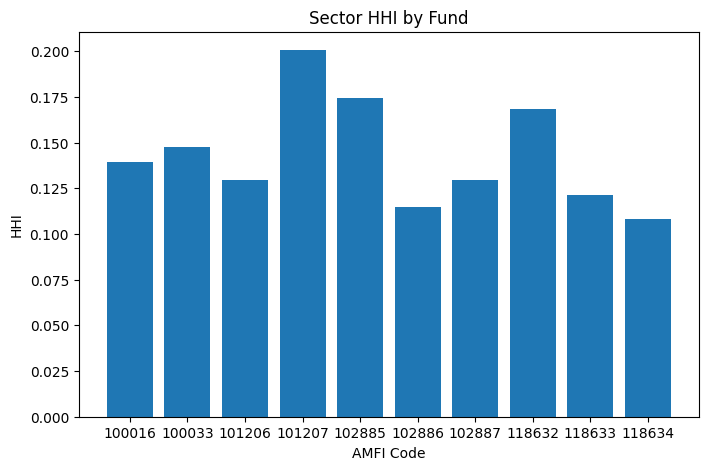

In [35]:
import matplotlib.pyplot as plt

top10 = sector_hhi.head(10)

plt.figure(figsize=(8,5))
plt.bar(top10["amfi_code"].astype(str), top10["HHI"])

plt.title("Sector HHI by Fund")
plt.xlabel("AMFI Code")
plt.ylabel("HHI")

plt.savefig("sector_hhi_chart.png")
plt.show()

# Advanced Analytics Insights

1. Funds with higher negative VaR values indicate greater downside risk.

2. CVaR values are lower than VaR, showing deeper losses during worst-case periods.

3. The 2024 investor cohort contributed the highest total investment and investor count.

4. Several SIP investors were classified as "At Risk" due to average transaction gaps exceeding 35 days.

5. Mid-cap funds dominated the Moderate risk recommendations based on return scores.